In [1]:
import cloudViewer as cv3d
import numpy as np
import os
import sys

# monkey patches visualization and provides helpers to load geometries
sys.path.append('..')
import cloudViewer_tutorial as cv3dtut
# change to True if you want to interact with the visualization windows
cv3dtut.interactive = not "CI" in os.environ

Using external CloudViewer-ML in /root/CloudViewer-ML


# Working with NumPy
All data structures in CloudViewer are natively compatible with a [NumPy](https://numpy.org/) buffer. The following tutorial generates a variant of sync function using NumPy and visualizes the function using CloudViewer.

First, we generate a $n \times 3$ matrix `xyz`. Each column has $x$, $y$, and $z$ values of the function $z = \frac{sin(x^2 + y^2)}{x^2 + y^2}$. $z_\text{norm}$ is the normalized map of $z$ for the [0,1] range.

In [2]:
# Generate some neat n times 3 matrix using a variant of sync function
x = np.linspace(-3, 3, 401)
mesh_x, mesh_y = np.meshgrid(x, x)
z = np.sinc((np.power(mesh_x, 2) + np.power(mesh_y, 2)))
z_norm = (z - z.min()) / (z.max() - z.min())
xyz = np.zeros((np.size(mesh_x), 3))
xyz[:, 0] = np.reshape(mesh_x, -1)
xyz[:, 1] = np.reshape(mesh_y, -1)
xyz[:, 2] = np.reshape(z_norm, -1)
print('xyz')
print(xyz)

xyz
[[-3.         -3.          0.17846472]
 [-2.985      -3.          0.17440115]
 [-2.97       -3.          0.17063709]
 ...
 [ 2.97        3.          0.17063709]
 [ 2.985       3.          0.17440115]
 [ 3.          3.          0.17846472]]


## From NumPy to cloudViewer.ccPointCloud
CloudViewer provides conversion from a NumPy matrix to a vector of 3D vectors. By using `Vector3dVector`, a NumPy matrix can be directly assigned to `cloudViewer.ccPointCloud.points`.

In this manner, any similar data structure such as `cloudViewer.ccPointCloud.colors` or `cloudViewer.ccPointCloud.normals` can be assigned or modified using NumPy. The code below also saves the point cloud as a `ply` file for the next step.

In [3]:
# Pass xyz to CloudViewer.cv3d.geometry.ccPointCloud and visualize
pcd = cv3d.geometry.ccPointCloud()
pcd.set_points(cv3d.utility.Vector3dVector(xyz))
cv3d.io.write_point_cloud("sync.ply", pcd)

True

## From cloudViewer.ccPointCloud to NumPy
As shown in this example, `pcd_load.points` of type `Vector3dVector` is converted into a NumPy array using `np.asarray`.

xyz_load
[[-3.         -3.          0.17846473]
 [-2.9849999  -3.          0.17440115]
 [-2.97000003 -3.          0.17063709]
 ...
 [ 2.97000003  3.          0.17063709]
 [ 2.9849999   3.          0.17440115]
 [ 3.          3.          0.17846473]]
[CloudViewer WARNING] GLFW Error: X11: The DISPLAY environment variable is missing
[CloudViewer WARNING] GLFW initialized for headless rendering.


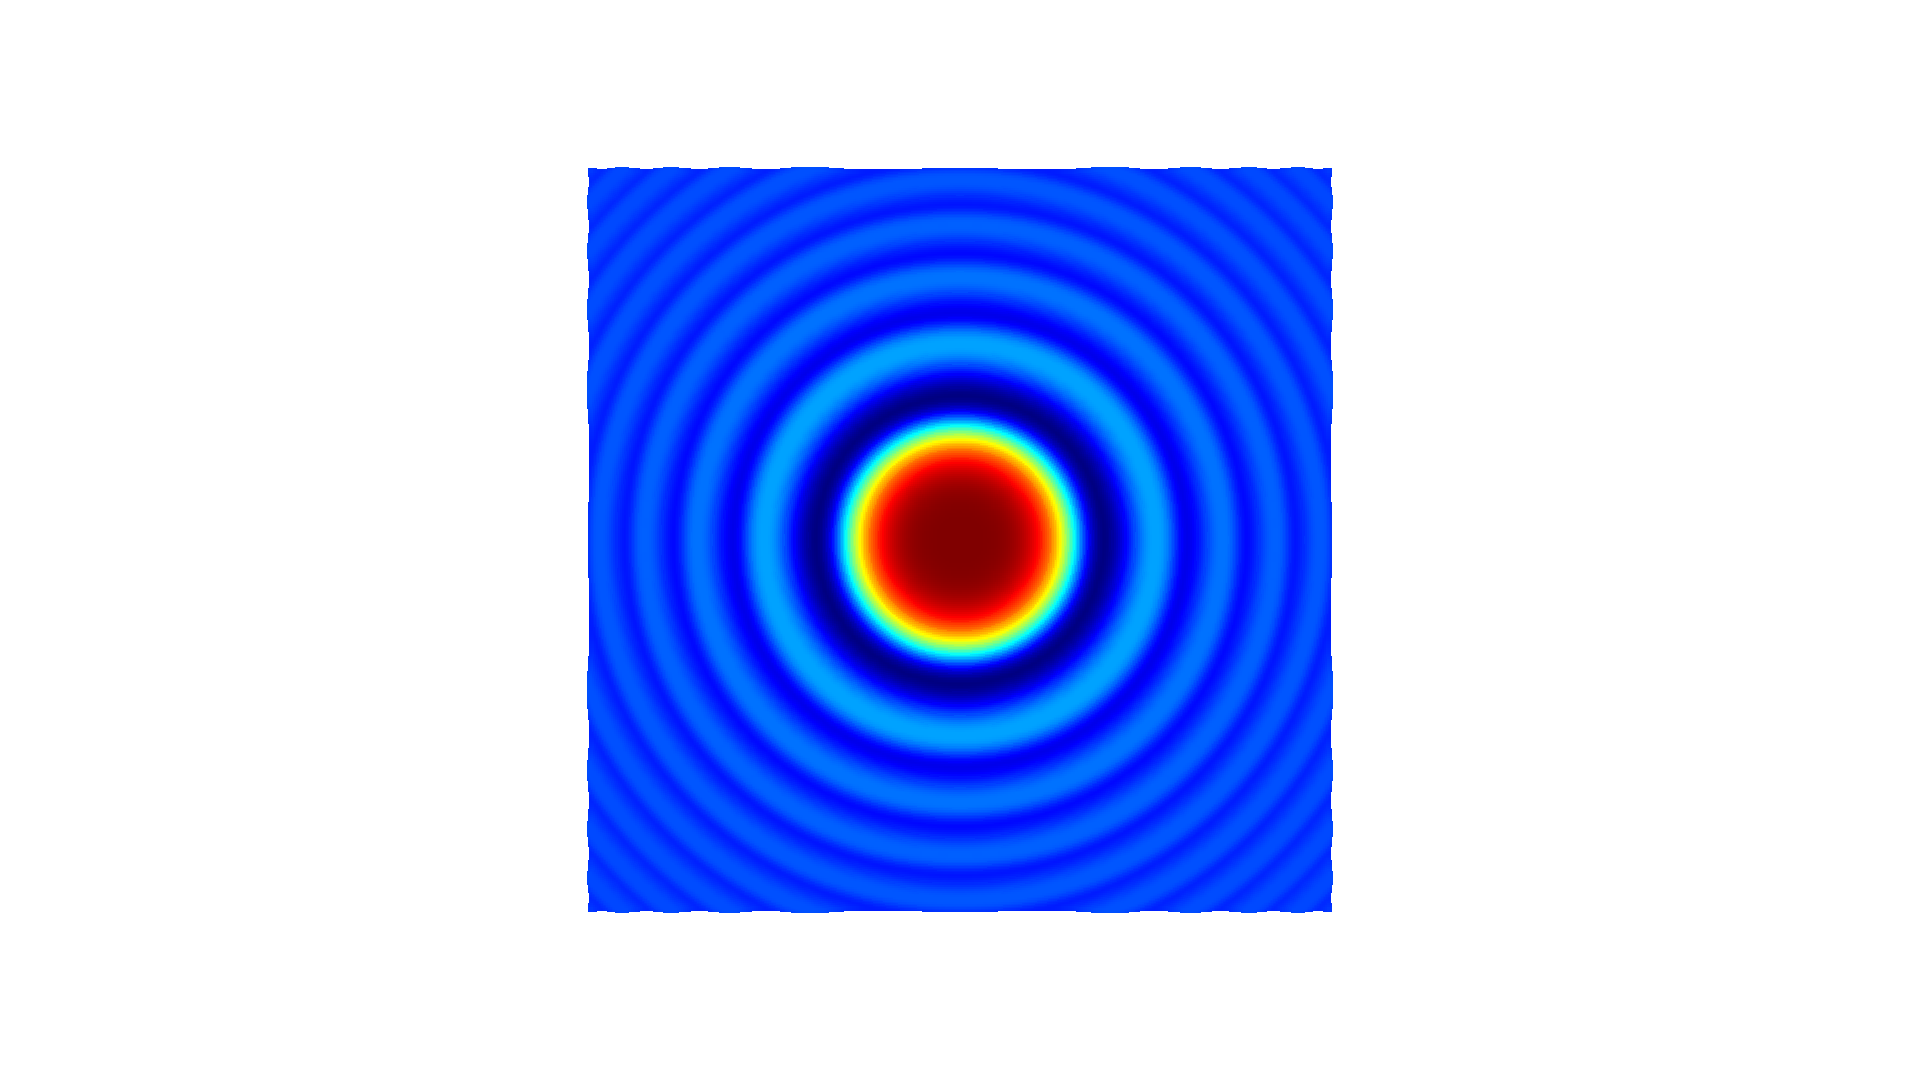

In [4]:
# Load saved point cloud and visualize it
pcd_load = cv3d.io.read_point_cloud("sync.ply")

# Convert CloudViewer.cv3d.geometry.ccPointCloud to numpy array
xyz_load = np.asarray(pcd_load.get_points())
print('xyz_load')
print(xyz_load)
cv3d.visualization.draw_geometries([pcd_load])
os.remove("sync.ply")